# 10. Hybrid Pipeline Experiments (Stage 1 + Stage 2)
In visual search, combining models yields superior results. Single models like standard YOLO miss detailed categories, and CLIP/FashionCLIP cannot localize on its own.
We combine:
- **Stage 1 (Detector)**: Grounding DINO (or YOLO) to detect candidate regions (regions containing any clothing/accessory item).
- **Stage 2 (Classifier)**: FashionCLIP to crop and classify each candidate region into fine-grained fashion classes.

In this notebook, we:
1. Initialize the `HybridPipeline` using dependency injection.
2. Run Stage 1 (Grounding DINO) to locate objects.
3. Run Stage 2 (FashionCLIP) to refine their labels.
4. Compare before (Stage 1) and after (Stage 2) classifications.



In [1]:
import os
import sys

sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.grounding_dino import GroundingDinoDetector
from fashion_detector.models.vision_llm import VisionLlmDetector
from fashion_detector.models.fashion_clip import FashionClipDetector
from fashion_detector.pipeline import HybridPipeline
from fashion_detector.utils import (
    load_image,
    generate_interactive_html,
    visualize_detections,
    display_img,
)
from IPython.display import HTML

config = Config("config/config.yaml")

# Instantiate components
detector = GroundingDinoDetector(config)
# vision_llm_detector = VisionLlmDetector(config)
classifier = FashionClipDetector(config)

# Instantiate the pipeline (Dependency Injection)
pipeline = HybridPipeline(detector=detector, classifier=classifier)

/Users/sunnyraj/code_files/git_repos/image-segments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-07-21 16:15:03] [INFO] [fashion_detector:config.py:159] - Configuration loaded from config/config.yaml. Device set to: mps


## Execute the Hybrid Pipeline


In [2]:
user_categories = [
    "dresses",
    "tops",
    "sweaters",
    "shirts",
    "jackets blazers",
    "coats",
    "pants",
    "jeans",
    "skirts",
    "suits sets",
    "jumpsuits",
    "sneakers",
    "flats",
    "loafers",
    "mules slides",
    "heels",
    "sandals",
    "boots",
    "tote bags",
    "shoulder bags",
    "crossbody bags",
    "handle bags",
    "backpacks",
    "belt bags",
    "clutches",
    "sunglasses",
    "scarves shawls",
    "belts",
    "wallets",
    "hats",
    "watches",
    "jewelry",
    "earrings",
    "necklaces",
    "bracelets",
    "rings",
    "brooches",
    "t shirts",
    "shirts",
    "sweaters",
    "jackets",
    "blazers",
    "coats",
    "pants",
    "jeans",
    "suits",
    "shorts",
    "dress shoes",
    "loafers",
    "sneakers",
    "boots",
    "sandals",
    "briefcases",
    "backpacks",
    "duffel bags",
    "messenger bags",
    "tote bags",
    "sunglasses",
    "belts",
    "ties",
    "scarves",
    "wallets",
    "hats",
    "watches",
]


def execute_pipeline(image_path, categories=user_categories):
    image = load_image(image_path)
    detections = pipeline.detect(image, categories=categories)
    print(f"Hybrid pipeline detected {len(detections)} fashion items:")
    for d in detections:
        print(
            f"- {d.label.capitalize()} (refined from {d.metadata.get('proposal_label')}): score={d.score:.2f}"
        )
    visualize_detections(image, detector._to_dict(detections))
    return detections

[2026-07-21 16:15:03] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: data/fashion_model_street.jpg
[2026-07-21 16:15:03] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:15:03] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:15:03] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:15:03] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:15:03] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:15:03] [INFO] [fashion_detector:grounding_dino.py:33] - Loading Grounding DINO model: IDEA-Research/grounding-dino-tiny on device: mps
[2026-07-21 16:15:09] [INFO] [fashion_detector:grounding_dino.py:46] - Grounding DINO model loaded successfully.
[2026-07-21 

/Users/sunnyraj/code_files/git_repos/image-segments/.venv/lib/python3.12/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:98: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


[2026-07-21 16:15:15] [INFO] [fashion_detector:grounding_dino.py:124] - Filtering out small box '' with area 447.0 pixels (min threshold: 1328.4)
[2026-07-21 16:15:15] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 9 items.
[2026-07-21 16:15:15] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.1961 seconds
[2026-07-21 16:15:15] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 3/4: ['footwear', 'wallet', 'bag', 'watch']
[2026-07-21 16:15:15] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:15:17] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 2 items.
[2026-07-21 16:15:17] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.1675 seconds
[2026-07-21 16:15:17] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 4/4: ['jewelry']
[2026-07-21 16:15:17] [INFO] [fashion_detector:logging.p

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[2026-07-21 16:15:24] [INFO] [fashion_detector:fashion_clip.py:46] - FashionCLIP model loaded successfully.
[2026-07-21 16:15:24] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-21 16:15:24] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.2806 seconds
[2026-07-21 16:15:24] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-21 16:15:24] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.0005 seconds
[2026-07-21 16:15:24] [INFO] [fashion_detector:pipeline.py:436] - Discarded false positive '['footwear']' matched to negative class 'background' with confidence 0.85
[2026-07-21 16:15:24] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-21 16:15:24] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.0950 seconds
[2026-07-21 16:15:24] [INFO] [fashion_detector:pipelin


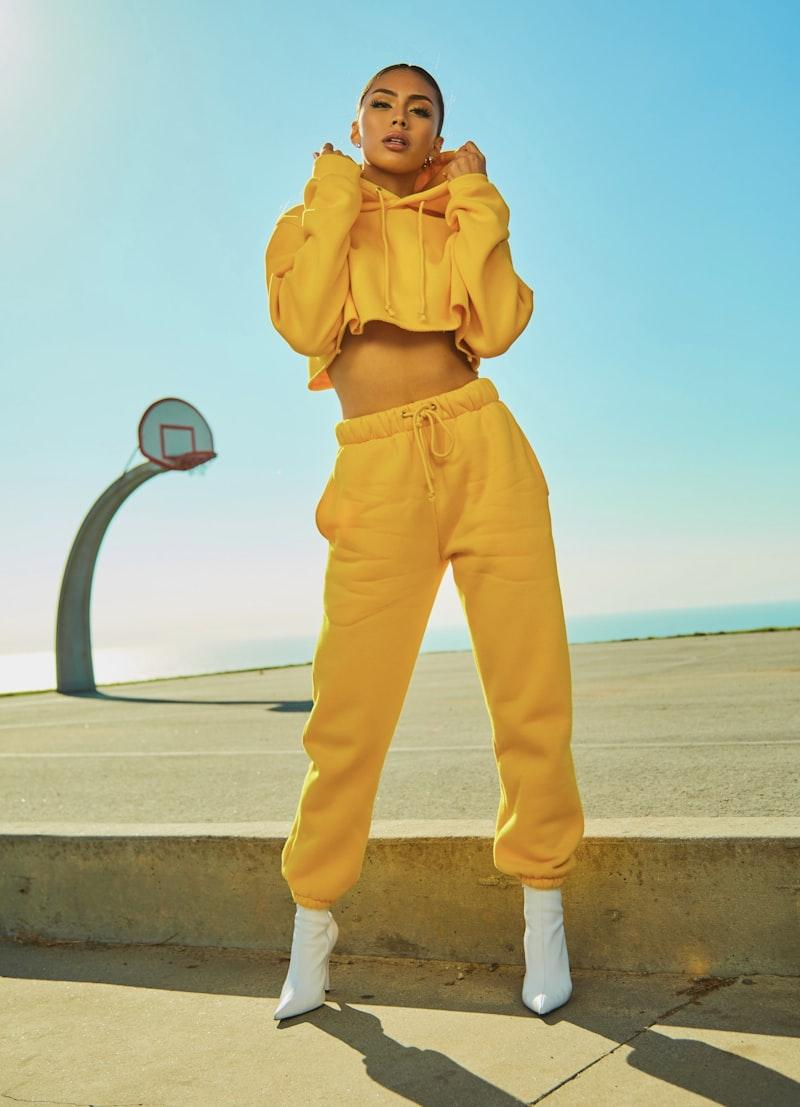

In [3]:
image_path = "data/fashion_model_street.jpg"
detections = execute_pipeline(image_path)

In [4]:
# detections = execute_pipeline('/Users/sunnyraj/Downloads/images.jpeg')

In [5]:
# detections = execute_pipeline('/Users/sunnyraj/Downloads/images-2.jpeg')

[2026-07-21 16:15:26] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-3.jpeg
[2026-07-21 16:15:26] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:15:26] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:15:26] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:15:26] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:15:26] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:15:28] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 4 items.
[2026-07-21 16:15:28] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.5886 seconds
[2026-07-21 16:15:28] [INFO] [fashion_det


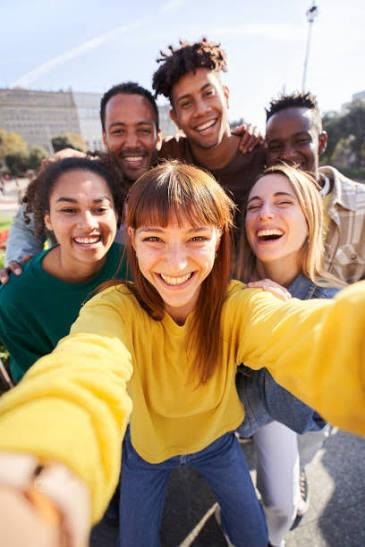

[2026-07-21 16:15:35] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-10.jpeg
[2026-07-21 16:15:35] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:15:35] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:15:35] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:15:35] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:15:35] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:15:38] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 8 items.
[2026-07-21 16:15:38] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.1870 seconds
[2026-07-21 16:15:38] [INFO] [fashion_de


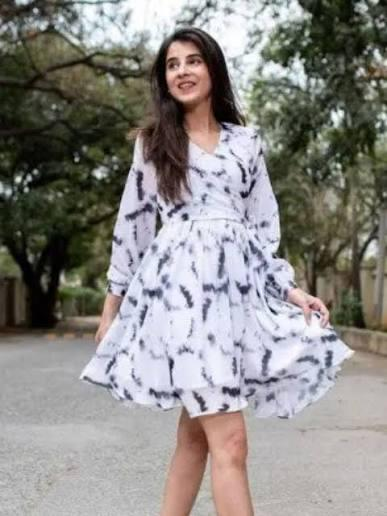

[2026-07-21 16:15:45] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-11.jpeg
[2026-07-21 16:15:45] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:15:45] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:15:45] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:15:45] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:15:45] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:15:47] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 7 items.
[2026-07-21 16:15:47] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.2048 seconds
[2026-07-21 16:15:47] [INFO] [fashion_de


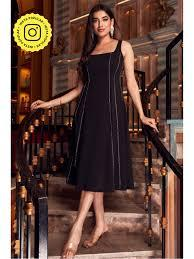

[2026-07-21 16:15:55] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images.jpeg
[2026-07-21 16:15:55] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:15:55] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:15:55] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:15:55] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:15:55] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:15:57] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 7 items.
[2026-07-21 16:15:57] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.6199 seconds
[2026-07-21 16:15:57] [INFO] [fashion_detec


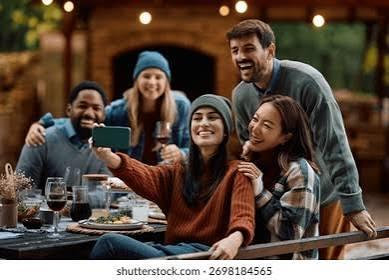

[2026-07-21 16:16:05] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-2.jpeg
[2026-07-21 16:16:05] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:16:05] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:16:05] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:16:05] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:16:05] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:16:08] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 4 items.
[2026-07-21 16:16:08] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 3.0668 seconds
[2026-07-21 16:16:08] [INFO] [fashion_det


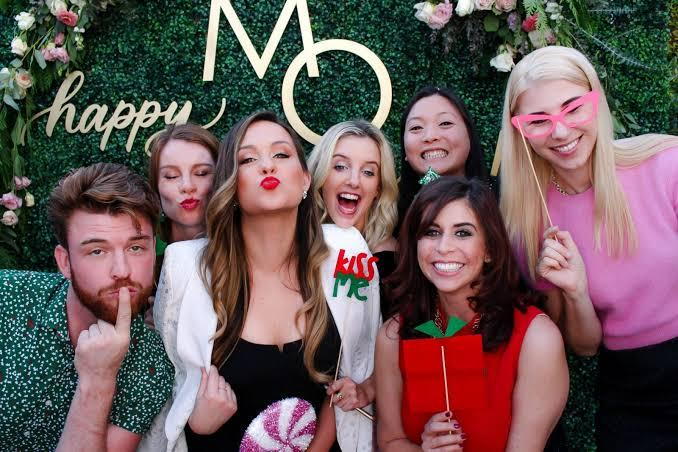

[2026-07-21 16:16:16] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-5.jpeg
[2026-07-21 16:16:16] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:16:16] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:16:16] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:16:16] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:16:16] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:16:19] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 6 items.
[2026-07-21 16:16:19] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.8318 seconds
[2026-07-21 16:16:19] [INFO] [fashion_det


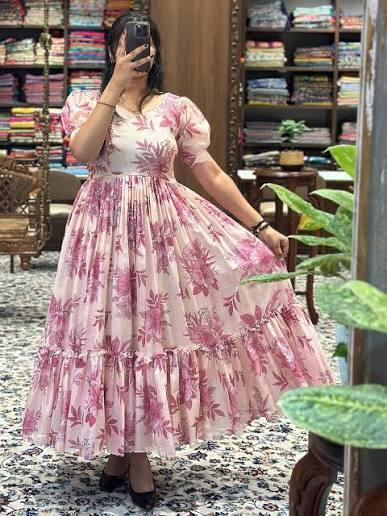

[2026-07-21 16:16:27] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-16.jpeg
[2026-07-21 16:16:27] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:16:27] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:16:27] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:16:27] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:16:27] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:16:30] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 7 items.
[2026-07-21 16:16:30] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.5554 seconds
[2026-07-21 16:16:30] [INFO] [fashion_de


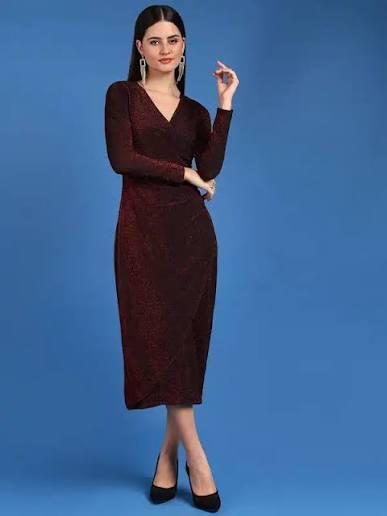

[2026-07-21 16:16:37] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-9.jpeg
[2026-07-21 16:16:37] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:16:37] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:16:37] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:16:37] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:16:37] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:16:40] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 6 items.
[2026-07-21 16:16:40] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 3.1209 seconds
[2026-07-21 16:16:40] [INFO] [fashion_det


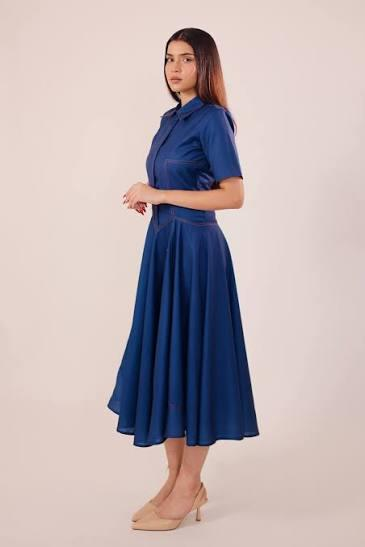

[2026-07-21 16:16:50] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-8.jpeg
[2026-07-21 16:16:50] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:16:50] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:16:50] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:16:50] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:16:50] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:16:53] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 6 items.
[2026-07-21 16:16:53] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 3.0026 seconds
[2026-07-21 16:16:53] [INFO] [fashion_det


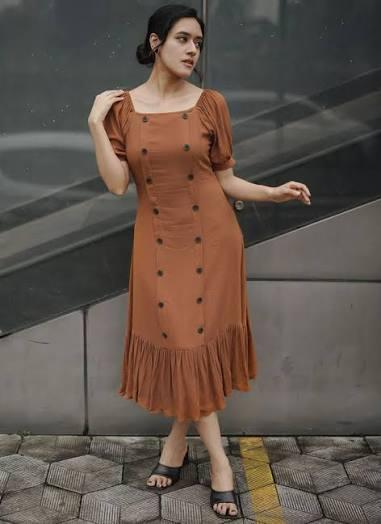

[2026-07-21 16:17:01] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-17.jpeg
[2026-07-21 16:17:01] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:17:01] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:17:01] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:17:01] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:17:01] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:17:04] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 7 items.
[2026-07-21 16:17:04] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 3.3874 seconds
[2026-07-21 16:17:04] [INFO] [fashion_de


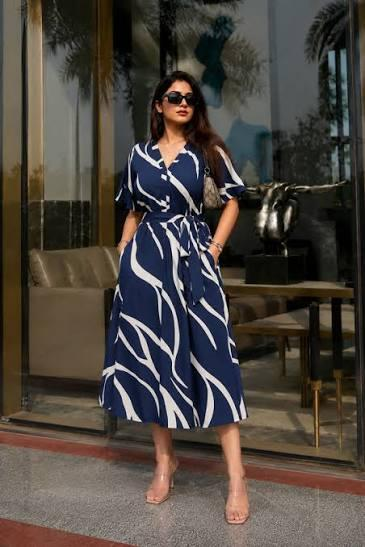

[2026-07-21 16:17:14] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-4.jpeg
[2026-07-21 16:17:14] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:17:14] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:17:14] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:17:14] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:17:14] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:17:17] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 6 items.
[2026-07-21 16:17:17] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.9058 seconds
[2026-07-21 16:17:17] [INFO] [fashion_det


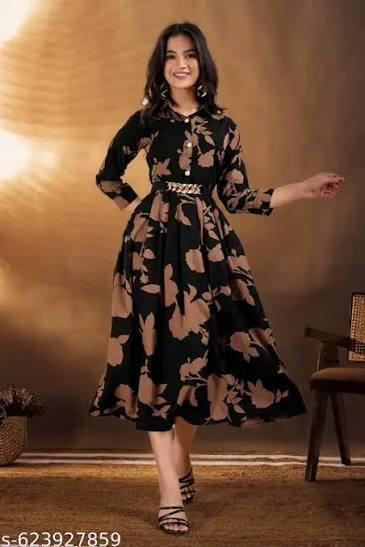

[2026-07-21 16:17:26] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-14.jpeg
[2026-07-21 16:17:26] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:17:26] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:17:26] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:17:26] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:17:26] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:17:29] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 5 items.
[2026-07-21 16:17:29] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.8816 seconds
[2026-07-21 16:17:29] [INFO] [fashion_de


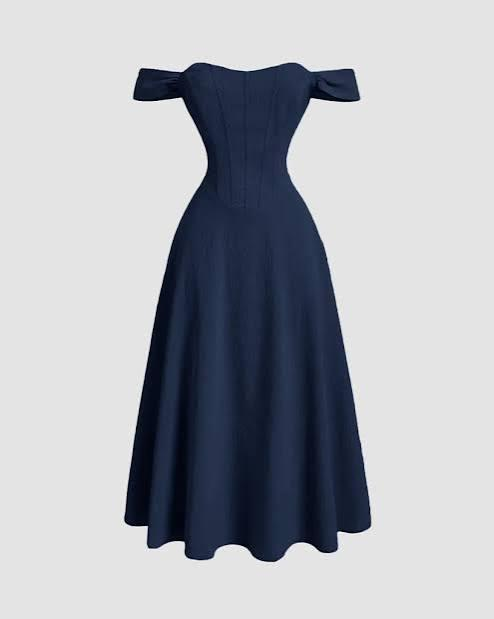

[2026-07-21 16:17:37] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-7.jpeg
[2026-07-21 16:17:37] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:17:37] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:17:37] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:17:37] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:17:37] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:17:41] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 5 items.
[2026-07-21 16:17:41] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 3.2197 seconds
[2026-07-21 16:17:41] [INFO] [fashion_det


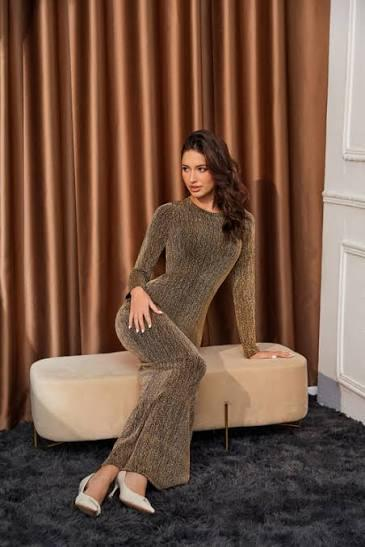

[2026-07-21 16:17:49] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-6.jpeg
[2026-07-21 16:17:49] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:17:49] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:17:49] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:17:49] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:17:49] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:17:52] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 5 items.
[2026-07-21 16:17:52] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.8600 seconds
[2026-07-21 16:17:52] [INFO] [fashion_det


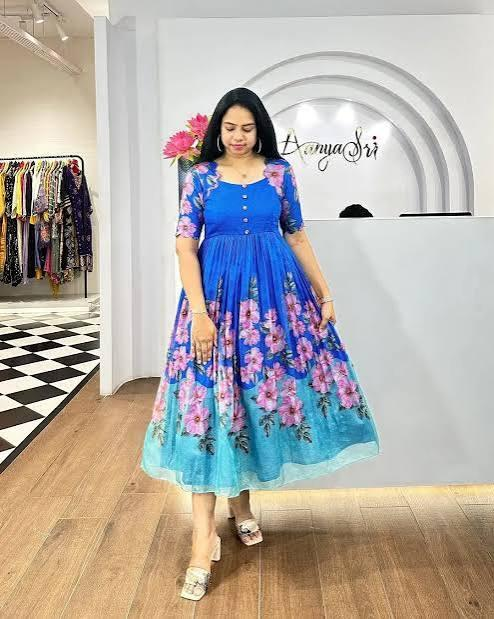

[2026-07-21 16:18:00] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-15.jpeg
[2026-07-21 16:18:00] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:18:00] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:18:00] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:18:00] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:18:00] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:18:03] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 5 items.
[2026-07-21 16:18:03] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.7722 seconds
[2026-07-21 16:18:03] [INFO] [fashion_de


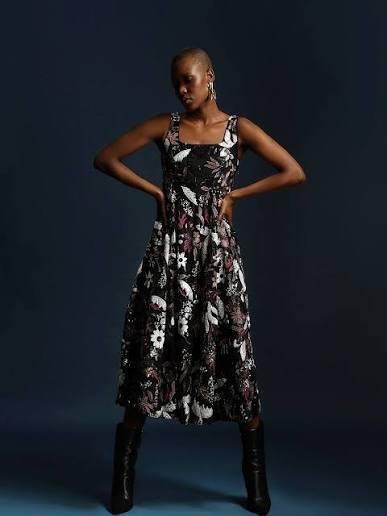

[2026-07-21 16:18:11] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-12.jpeg
[2026-07-21 16:18:11] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:18:11] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:18:11] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:18:11] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:18:11] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:18:14] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 7 items.
[2026-07-21 16:18:14] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 3.4416 seconds
[2026-07-21 16:18:14] [INFO] [fashion_de


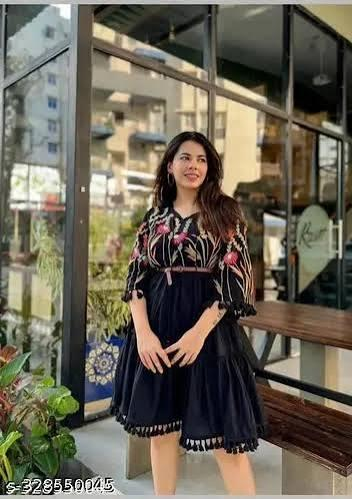

[2026-07-21 16:18:24] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-13.jpeg
[2026-07-21 16:18:24] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:18:24] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:18:24] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:18:24] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:18:24] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:18:27] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 6 items.
[2026-07-21 16:18:27] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.6599 seconds
[2026-07-21 16:18:27] [INFO] [fashion_de


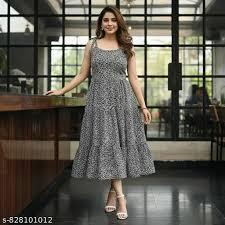

In [6]:
for image in os.listdir("/Users/sunnyraj/Downloads/"):
    if image.endswith(".jpeg") or image.endswith(".jpg") or image.endswith(".png"):
        image_path = os.path.join("/Users/sunnyraj/Downloads/", image)
        detections = execute_pipeline(image_path)

[2026-07-21 16:18:33] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-4.jpeg
[2026-07-21 16:18:33] [INFO] [fashion_detector:logging.py:98] - Starting: Hybrid Pipeline Total Execution
[2026-07-21 16:18:33] [INFO] [fashion_detector:pipeline.py:245] - Executing Stage 1: Region Proposal...
[2026-07-21 16:18:33] [INFO] [fashion_detector:pipeline.py:266] - Hierarchical Mode: Map target categories to 13 parent queries.
[2026-07-21 16:18:33] [INFO] [fashion_detector:pipeline.py:277] - Running Grounding DINO Batch 1/4: ['ties', 'belt', 'headwear', 'one-piece dress, suit, jumpsuit']
[2026-07-21 16:18:33] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:18:35] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 6 items.
[2026-07-21 16:18:35] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 2.8329 seconds
[2026-07-21 16:18:35] [INFO] [fashion_det


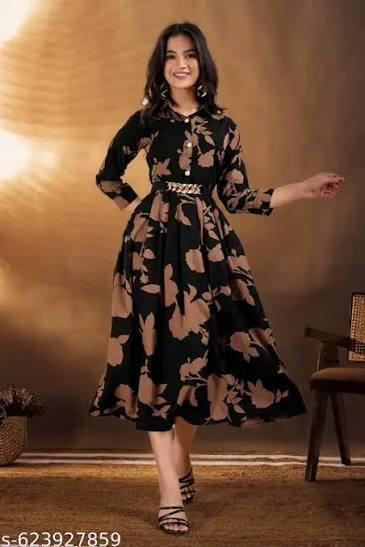

In [7]:
detections = execute_pipeline("/Users/sunnyraj/Downloads/images-4.jpeg")

[2026-07-21 16:18:44] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-13.jpeg
[2026-07-21 16:18:44] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 16:18:47] [INFO] [fashion_detector:grounding_dino.py:124] - Filtering out small box 'bracelets' with area 36.9 pixels (min threshold: 150.0)
[2026-07-21 16:18:47] [INFO] [fashion_detector:grounding_dino.py:124] - Filtering out small box '##s' with area 98.6 pixels (min threshold: 150.0)
[2026-07-21 16:18:47] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 5 items.
[2026-07-21 16:18:47] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 3.6001 seconds
Hybrid pipeline detected 5 fashion items:
- Dresses jumpsuits (refined from None): score=0.42
- Heels sandals sandals (refined from None): score=0.34
- Heels sandals sandals (refined from None): score=0.35
- Heels dress shoes (refined from Non


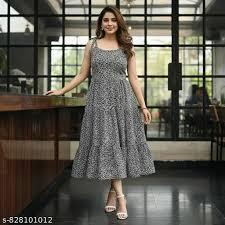

In [8]:
image = load_image(image_path)
detections = detector.detect(image, queries=user_categories)
print(f"Hybrid pipeline detected {len(detections)} fashion items:")
for d in detections:
    print(
        f"- {d.label.capitalize()} (refined from {d.metadata.get('proposal_label')}): score={d.score:.2f}"
    )
visualize_detections(image, detector._to_dict(detections))

[2026-07-21 17:34:17] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-2.jpeg
[2026-07-21 17:34:17] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 17:34:18] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 7 items.
[2026-07-21 17:34:18] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 1.3446 seconds
Hybrid pipeline detected 7 fashion items:
- Clothes (refined from None): score=0.69
- Clothes (refined from None): score=0.64
- Clothes (refined from None): score=0.58
- Clothes (refined from None): score=0.33
- Clothes (refined from None): score=0.29
- Clothes (refined from None): score=0.25
- Clothes (refined from None): score=0.29



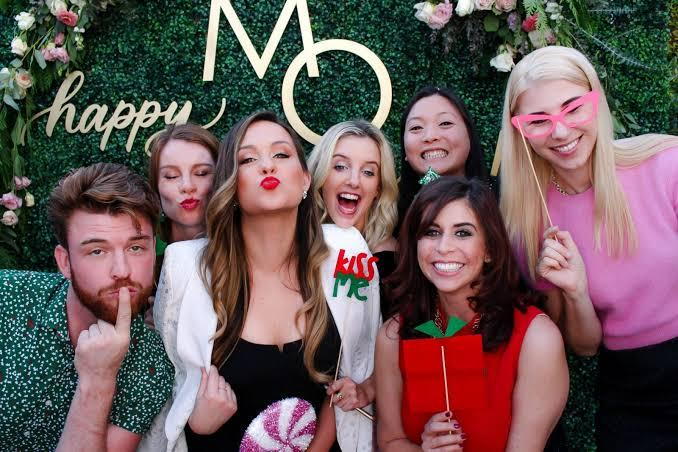

In [70]:
image_path = "/Users/sunnyraj/Downloads/images-2.jpeg"
image = load_image(image_path)
detections = detector.detect(image, queries=["clothes"])
print(f"Hybrid pipeline detected {len(detections)} fashion items:")
for d in detections:
    print(
        f"- {d.label.capitalize()} (refined from {d.metadata.get('proposal_label')}): score={d.score:.2f}"
    )
visualize_detections(image, detector._to_dict(detections))

In [59]:
import torch
import numpy as np
from PIL import Image


def native_weighted_boxes_fusion(boxes, scores, labels, iou_thr=0.5):
    """
    Pure Python/NumPy implementation of Weighted Boxes Fusion (WBF).
    Handles a single list of boxes, scores, and labels directly.
    """
    if len(boxes) == 0:
        return np.array([]), np.array([]), np.array([])

    boxes = np.array(boxes)
    scores = np.array(scores)
    labels = np.array(labels)

    # Sort detections by confidence score in descending order
    indices = np.argsort(scores)[::-1]
    boxes = boxes[indices]
    scores = scores[indices]
    labels = labels[indices]

    clusters = []

    for i in range(len(boxes)):
        box = boxes[i]
        score = scores[i]
        label = labels[i]

        matched = False
        for cluster in clusters:
            # Only cluster boxes that share the identical class label
            if label != cluster["label"]:
                continue

            # Calculate Intersection over Union (IoU) with the cluster average box
            c_box = cluster["box"]
            xA = max(box[0], c_box[0])
            yA = max(box[1], c_box[1])
            xB = min(box[2], c_box[2])
            yB = min(box[3], c_box[3])

            inter_area = max(0, xB - xA) * max(0, yB - yA)
            box_area = (box[2] - box[0]) * (box[3] - box[1])
            c_box_area = (c_box[2] - c_box[0]) * (c_box[3] - c_box[1])
            union_area = box_area + c_box_area - inter_area
            iou = inter_area / union_area if union_area > 0 else 0

            if iou > iou_thr:
                cluster["boxes"].append(box)
                cluster["scores"].append(score)
                # Recalculate weighted coordinates dynamically
                w_sum = sum(cluster["scores"])
                new_box = np.zeros(4)
                for b, s in zip(cluster["boxes"], cluster["scores"]):
                    new_box += b * s
                cluster["box"] = new_box / w_sum
                matched = True
                break

        if not matched:
            clusters.append(
                {"label": label, "box": box, "boxes": [box], "scores": [score]}
            )

    final_boxes = [c["box"] for c in clusters]
    final_scores = [max(c["scores"]) for c in clusters]
    final_labels = [c["label"] for c in clusters]

    return final_boxes, final_scores, final_labels


class MultiBatchFashionDetector:
    def __init__(self, dino_detector):
        self.dino_detector = dino_detector
        self.device = dino_detector.device
        self.processor = dino_detector.processor
        self.model = dino_detector.model

        # Optimized Parallel Batches
        self.batches = {
            "apparel": "dress . top . t shirt . shirt . sweater . jacket . blazer . coat . pants . jeans . shorts . skirt . suit . jumpsuit .",
            "footwear_bags": "sneakers . flat shoes . loafers . mules . slides . heels . sandals . boots . dress shoes . tote bag . shoulder bag . crossbody bag . handle bag . backpack . belt bag . clutch . briefcase . duffel bag . messenger bag .",
            "accessories": "sunglasses . scarf . shawl . belt . tie . wallet . hat . watch . jewelry . earrings . necklace . bracelet . ring . brooch .",
        }

        # Taxonomy Mapper
        self.class_mapping = {
            "dress": "dresses",
            "top": "tops",
            "t shirt": "t shirts",
            "shirt": "shirts",
            "sweater": "sweaters",
            "jacket": "jackets",
            "blazer": "blazers",
            "coat": "coats",
            "pants": "pants",
            "jeans": "jeans",
            "shorts": "shorts",
            "skirt": "skirts",
            "suit": "suits sets",
            "jumpsuit": "jumpsuits",
            "sneakers": "sneakers",
            "flat shoes": "flats",
            "loafers": "loafers",
            "mules": "mules slides",
            "slides": "mules slides",
            "heels": "heels",
            "sandals": "sandals",
            "boots": "boots",
            "dress shoes": "dress shoes",
            "tote bag": "tote bags",
            "shoulder bag": "shoulder bags",
            "crossbody bag": "crossbody bags",
            "handle bag": "handle bags",
            "backpack": "backpacks",
            "belt bag": "belt bags",
            "clutch": "clutches",
            "briefcase": "briefcases",
            "duffel bag": "duffel bags",
            "messenger bag": "messenger bags",
            "sunglasses": "sunglasses",
            "scarf": "scarves shawls",
            "shawl": "scarves shawls",
            "belt": "belts",
            "tie": "ties",
            "wallet": "wallets",
            "hat": "hats",
            "watch": "watches",
            "jewelry": "jewelry",
            "earrings": "earrings",
            "necklace": "necklaces",
            "bracelet": "bracelets",
            "ring": "rings",
            "brooch": "brooches",
        }

        # Generate stable integer IDs for each target class label
        self.unique_labels = list(set(self.class_mapping.values()))
        self.label_to_id = {label: idx for idx, label in enumerate(self.unique_labels)}
        self.id_to_label = {idx: label for idx, label in enumerate(self.unique_labels)}

    def detect(
        self, image_path: str, box_thresh=0.30, text_thresh=0.25, iou_thresh=0.50
    ):
        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        raw_boxes, raw_scores, raw_labels = [], [], []

        # Step 1: Run Independent Batches
        for batch_name, prompt in self.batches.items():
            # print(f"Processing batch '{batch_name}' with prompt: {prompt}")
            results = self.dino_detector.detect(image, queries=[prompt])
            results = self.dino_detector._to_dict(results)
            # print(f"Results: {results}")

            for item in results:
                label = item.get("label", "").strip().lower()
                # Filter out sub-word BERT fragments (like "##uit" or empty spaces)
                if label.startswith("##") or not label:
                    continue

                score = float(item.get("score", 0.0))
                box = item.get("box", None)
                mapped_label = self.class_mapping.get(label.strip().lower(), None)
                if mapped_label:
                    # Normalize box coordinates to [0, 1] range for WBF processing
                    norm_box = [
                        float(box[0]) / width,
                        float(box[1]) / height,
                        float(box[2]) / width,
                        float(box[3]) / height,
                    ]
                    raw_boxes.append(norm_box)
                    raw_scores.append(float(score))
                    raw_labels.append(self.label_to_id[mapped_label])

        if not raw_boxes:
            return []

        # Step 2: Apply Weighted Boxes Fusion (WBF)
        # Expects a nested list configuration for multi-model / multi-batch setups
        wbf_boxes, wbf_scores, wbf_labels = native_weighted_boxes_fusion(
            boxes=raw_boxes,
            scores=raw_scores,
            labels=raw_labels,
            iou_thr=iou_thresh,
        )

        # Step 3: Format Outputs back to Original Pixel Scale
        final_detections = []
        for box, score, label_id in zip(wbf_boxes, wbf_scores, wbf_labels):
            pixel_box = [
                int(box[0] * width),  # xmin
                int(box[1] * height),  # ymin
                int(box[2] * width),  # xmax
                int(box[3] * height),  # ymax
            ]
            final_detections.append(
                {
                    "label": self.id_to_label[int(label_id)],
                    "confidence": float(score),
                    "box": pixel_box,
                }
            )

        return final_detections

In [60]:
multi_batch_detector = MultiBatchFashionDetector(detector)

[2026-07-21 17:31:14] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-13.jpeg
[2026-07-21 17:31:14] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 17:31:15] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 2 items.
[2026-07-21 17:31:15] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 0.9890 seconds
[2026-07-21 17:31:15] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 17:31:15] [INFO] [fashion_detector:grounding_dino.py:138] - Grounding DINO detected 4 items.
[2026-07-21 17:31:15] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 0.9116 seconds
[2026-07-21 17:31:15] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-21 17:31:16] [INFO] [fashion_detector:grounding_dino.py:124] - Filtering out small box 'bracelet' with area 24.5


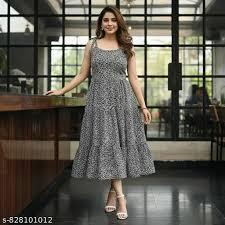

In [62]:
image = load_image(image_path)
detections = multi_batch_detector.detect(image_path)
print(f"Hybrid pipeline detected {len(detections)} fashion items:")
for d in detections:
    print(f"- {d['label'].capitalize()} : score={d['confidence']:.2f}")
visualize_detections(image, detections)